# Comprehensive Sensitivity Analysis for Process Mining Pipeline

This notebook performs a thorough sensitivity analysis to evaluate the robustness, stability, and interpretability of a process mining pipeline. The analysis includes:

- **Local sensitivity (OAT)**: One-at-a-time parameter variations
- **Global sensitivity (Sobol)**: Variance-based analysis using SALib
- **Statistical validation**: Confidence intervals and significance testing
- **Comprehensive visualization**: Tornado plots, heatmaps, CDFs, and reliability diagrams

All process mining metrics are computed using pm4py wherever possible.

## 1. Import Required Libraries

Import all necessary libraries for process mining, sensitivity analysis, statistics, and visualization.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Dict, List, Tuple, Any, Callable, Optional
import time
import warnings
from dataclasses import dataclass
from scipy import stats
from scipy.interpolate import interp1d

import pm4py
from pm4py.objects.log.obj import EventLog, Event, Trace
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

from SALib.sample import saltelli
from SALib.analyze import sobol

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 2. Define Helper Functions for Metrics Computation

Create typed helper functions to compute all relevant metrics including pm4py process mining metrics, diagnostic accuracy, runtime, and explainability indicators.

In [9]:
@dataclass
class ProcessMetrics:
    fitness: float
    precision: float
    generalization: float
    simplicity: float
    conformance_rate: float
    diagnostic_accuracy: float
    posterior_entropy: float
    runtime_seconds: float
    n_places: int
    n_transitions: int
    n_arcs: int


def compute_fitness(log: EventLog, net: PetriNet, im: Marking, fm: Marking) -> float:
    """
    Compute fitness metric using pm4py token-based replay.
    
    Args:
        log: Event log to evaluate
        net: Petri net model
        im: Initial marking
        fm: Final marking
    
    Returns:
        Fitness value between 0 and 1
    """
    fitness_result = replay_fitness.apply(log, net, im, fm, variant=replay_fitness.Variants.TOKEN_BASED)
    return fitness_result['average_trace_fitness']


def compute_precision(log: EventLog, net: PetriNet, im: Marking, fm: Marking) -> float:
    """
    Compute precision metric using pm4py.
    
    Args:
        log: Event log to evaluate
        net: Petri net model
        im: Initial marking
        fm: Final marking
    
    Returns:
        Precision value between 0 and 1
    """
    prec = precision_evaluator.apply(log, net, im, fm, variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN)
    return prec


def compute_generalization(log: EventLog, net: PetriNet, im: Marking, fm: Marking) -> float:
    """
    Compute generalization metric using pm4py.
    
    Args:
        log: Event log to evaluate
        net: Petri net model
        im: Initial marking
        fm: Final marking
    
    Returns:
        Generalization value between 0 and 1
    """
    gen = generalization_evaluator.apply(log, net, im, fm)
    return gen


def compute_simplicity(net: PetriNet) -> float:
    """
    Compute simplicity metric using pm4py.
    
    Args:
        net: Petri net model
    
    Returns:
        Simplicity value between 0 and 1
    """
    simp = simplicity_evaluator.apply(net)
    return simp


def compute_conformance_rate(log: EventLog, net: PetriNet, im: Marking, fm: Marking, threshold: float) -> float:
    """
    Compute the rate of conforming traces based on fitness threshold.
    
    Args:
        log: Event log to evaluate
        net: Petri net model
        im: Initial marking
        fm: Final marking
        threshold: Minimum fitness for conformance
    
    Returns:
        Proportion of conforming traces
    """
    replayed_traces = token_replay.apply(log, net, im, fm)
    conforming = sum(1 for trace in replayed_traces if trace['trace_fitness'] >= threshold)
    return conforming / len(replayed_traces) if replayed_traces else 0.0


def compute_posterior_entropy(posterior_probs: np.ndarray) -> float:
    """
    Compute Shannon entropy of posterior probabilities.
    
    Args:
        posterior_probs: Array of posterior probability distributions
    
    Returns:
        Average entropy across all posteriors
    """
    eps = 1e-10
    posterior_probs = np.clip(posterior_probs, eps, 1.0)
    entropies = -np.sum(posterior_probs * np.log2(posterior_probs), axis=-1)
    return float(np.mean(entropies))


def compute_diagnostic_accuracy(predictions: np.ndarray, ground_truth: np.ndarray) -> float:
    """
    Compute diagnostic accuracy as proportion of correct predictions.
    
    Args:
        predictions: Predicted class labels
        ground_truth: True class labels
    
    Returns:
        Accuracy between 0 and 1
    """
    return float(np.mean(predictions == ground_truth))


def get_model_complexity(net: PetriNet) -> Tuple[int, int, int]:
    """
    Extract structural complexity metrics from Petri net.
    
    Args:
        net: Petri net model
    
    Returns:
        Tuple of (n_places, n_transitions, n_arcs)
    """
    n_places = len(net.places)
    n_transitions = len(net.transitions)
    n_arcs = len(net.arcs)
    return n_places, n_transitions, n_arcs

## 3. Define Helper Functions for Visualization

Create typed helper functions for generating all required visualization types using matplotlib.

In [10]:
def plot_tornado(
    param_names: List[str],
    metric_impacts: Dict[str, List[float]],
    metric_name: str,
    output_path: Optional[str] = None
) -> None:
    """
    Generate a tornado plot showing parameter impacts on a metric.
    
    Args:
        param_names: List of parameter names
        metric_impacts: Dictionary mapping metric names to impact values
        metric_name: Name of the metric being visualized
        output_path: Optional path to save the figure
    """
    impacts = metric_impacts[metric_name]
    sorted_indices = np.argsort(np.abs(impacts))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = np.arange(len(param_names))
    
    colors = ['#d62728' if x < 0 else '#2ca02c' for x in np.array(impacts)[sorted_indices]]
    ax.barh(y_pos, np.array(impacts)[sorted_indices], color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([param_names[i] for i in sorted_indices])
    ax.set_xlabel(f'Impact on {metric_name}')
    ax.set_title(f'Tornado Plot: Parameter Impact on {metric_name}')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_partial_dependence(
    param_values: np.ndarray,
    metric_values: np.ndarray,
    metric_errors: np.ndarray,
    param_name: str,
    metric_name: str,
    output_path: Optional[str] = None
) -> None:
    """
    Generate partial dependence plot with confidence intervals.
    
    Args:
        param_values: Array of parameter values
        metric_values: Mean metric values at each parameter value
        metric_errors: Standard errors for confidence intervals
        param_name: Name of the parameter
        metric_name: Name of the metric
        output_path: Optional path to save the figure
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(param_values, metric_values, 'o-', linewidth=2, markersize=8, label='Mean')
    ax.fill_between(
        param_values,
        metric_values - 1.96 * metric_errors,
        metric_values + 1.96 * metric_errors,
        alpha=0.3,
        label='95% CI'
    )
    
    ax.set_xlabel(param_name)
    ax.set_ylabel(metric_name)
    ax.set_title(f'Partial Dependence: {metric_name} vs {param_name}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_sobol_indices(
    param_names: List[str],
    S1: np.ndarray,
    ST: np.ndarray,
    S1_conf: np.ndarray,
    ST_conf: np.ndarray,
    metric_name: str,
    output_path: Optional[str] = None
) -> None:
    """
    Generate bar chart for Sobol indices with confidence intervals.
    
    Args:
        param_names: List of parameter names
        S1: First-order Sobol indices
        ST: Total-order Sobol indices
        S1_conf: Confidence intervals for S1
        ST_conf: Confidence intervals for ST
        metric_name: Name of the metric
        output_path: Optional path to save the figure
    """
    x = np.arange(len(param_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.bar(x - width/2, S1, width, yerr=S1_conf, label='First-order (S1)', 
           capsize=5, alpha=0.8, color='#1f77b4')
    ax.bar(x + width/2, ST, width, yerr=ST_conf, label='Total-order (ST)', 
           capsize=5, alpha=0.8, color='#ff7f0e')
    
    ax.set_xlabel('Parameters')
    ax.set_ylabel('Sobol Index')
    ax.set_title(f'Sobol Sensitivity Indices for {metric_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(param_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_interaction_heatmap(
    param_names: List[str],
    S2: np.ndarray,
    metric_name: str,
    output_path: Optional[str] = None
) -> None:
    """
    Generate heatmap for second-order Sobol indices (interactions).
    
    Args:
        param_names: List of parameter names
        S2: Second-order Sobol indices matrix
        metric_name: Name of the metric
        output_path: Optional path to save the figure
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(S2, cmap='YlOrRd', aspect='auto', vmin=0)
    
    ax.set_xticks(np.arange(len(param_names)))
    ax.set_yticks(np.arange(len(param_names)))
    ax.set_xticklabels(param_names, rotation=45, ha='right')
    ax.set_yticklabels(param_names)
    
    for i in range(len(param_names)):
        for j in range(len(param_names)):
            if i != j:
                text = ax.text(j, i, f'{S2[i, j]:.3f}', ha='center', va='center', 
                             color='black' if S2[i, j] < 0.1 else 'white', fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Second-order Sobol Index', rotation=270, labelpad=20)
    
    ax.set_title(f'Parameter Interactions for {metric_name}')
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_boxplot_comparison(
    data: Dict[str, np.ndarray],
    metric_name: str,
    output_path: Optional[str] = None
) -> None:
    """
    Generate box and violin plots for metric distributions.
    
    Args:
        data: Dictionary mapping parameter names to metric arrays
        metric_name: Name of the metric
        output_path: Optional path to save the figure
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    positions = list(range(len(data)))
    labels = list(data.keys())
    values = [data[key] for key in labels]
    
    bp = ax1.boxplot(values, positions=positions, labels=labels, patch_artist=True,
                     showmeans=True, meanline=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.7)
    
    ax1.set_ylabel(metric_name)
    ax1.set_title(f'Box Plot: {metric_name} Distribution')
    ax1.grid(axis='y', alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    parts = ax2.violinplot(values, positions=positions, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#ff7f0e')
        pc.set_alpha(0.7)
    
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylabel(metric_name)
    ax2.set_title(f'Violin Plot: {metric_name} Distribution')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_cdf(
    metric_values: np.ndarray,
    metric_name: str,
    threshold: Optional[float] = None,
    output_path: Optional[str] = None
) -> None:
    """
    Generate cumulative distribution function plot for robustness assessment.
    
    Args:
        metric_values: Array of metric values
        metric_name: Name of the metric
        threshold: Optional threshold line to display
        output_path: Optional path to save the figure
    """
    sorted_values = np.sort(metric_values)
    cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(sorted_values, cdf, linewidth=2, label='Empirical CDF')
    
    if threshold is not None:
        ax.axvline(x=threshold, color='r', linestyle='--', linewidth=2, 
                  label=f'Threshold = {threshold:.3f}')
        prob_above = np.mean(metric_values >= threshold)
        ax.text(threshold, 0.5, f'P(X ≥ {threshold:.3f}) = {prob_above:.3f}',
               rotation=90, verticalalignment='center', backgroundcolor='white')
    
    ax.set_xlabel(metric_name)
    ax.set_ylabel('Cumulative Probability')
    ax.set_title(f'CDF: {metric_name} Robustness Assessment')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_reliability_diagram(
    predicted_probs: np.ndarray,
    true_labels: np.ndarray,
    n_bins: int = 10,
    output_path: Optional[str] = None
) -> None:
    """
    Generate reliability diagram (calibration plot) for Bayesian reasoning.
    
    Args:
        predicted_probs: Predicted probabilities
        true_labels: True binary labels
        n_bins: Number of bins for calibration
        output_path: Optional path to save the figure
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_indices = np.digitize(predicted_probs, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    bin_sums = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins)
    bin_true = np.zeros(n_bins)
    
    for i in range(n_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_counts[i] = np.sum(mask)
            bin_sums[i] = np.sum(predicted_probs[mask])
            bin_true[i] = np.sum(true_labels[mask])
    
    bin_means = np.divide(bin_sums, bin_counts, where=bin_counts > 0)
    bin_accuracies = np.divide(bin_true, bin_counts, where=bin_counts > 0)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect calibration')
    
    valid_bins = bin_counts > 0
    ax.plot(bin_means[valid_bins], bin_accuracies[valid_bins], 'o-', 
           linewidth=2, markersize=10, label='Model calibration')
    
    for i in range(n_bins):
        if bin_counts[i] > 0:
            ax.bar(bin_centers[i], bin_counts[i] / np.max(bin_counts) * 0.1,
                  width=0.08, alpha=0.3, color='gray', bottom=0)
    
    ece = np.sum(bin_counts * np.abs(bin_accuracies - bin_means)) / np.sum(bin_counts)
    
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Observed Frequency')
    ax.set_title(f'Reliability Diagram (ECE = {ece:.4f})')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

## 4. Generate or Load Event Log Data

Generate a synthetic event log using pm4py with configurable parameters to simulate a realistic process mining scenario.

In [11]:
def generate_synthetic_log(
    n_traces: int = 100,
    min_events: int = 5,
    max_events: int = 15,
    activities: Optional[List[str]] = None,
    noise_level: float = 0.0,
    random_seed: int = 42
) -> EventLog:
    """
    Generate a synthetic event log for process mining.
    
    Args:
        n_traces: Number of traces to generate
        min_events: Minimum events per trace
        max_events: Maximum events per trace
        activities: List of activity names (default: A-H)
        noise_level: Proportion of random noise events
        random_seed: Random seed for reproducibility
    
    Returns:
        Generated event log
    """
    np.random.seed(random_seed)
    
    if activities is None:
        activities = ['Register', 'Examine', 'Test_Blood', 'Test_Xray', 
                     'Diagnose', 'Prescribe', 'Treatment', 'Discharge']
    
    normal_patterns = [
        ['Register', 'Examine', 'Diagnose', 'Prescribe', 'Discharge'],
        ['Register', 'Examine', 'Test_Blood', 'Diagnose', 'Prescribe', 'Discharge'],
        ['Register', 'Examine', 'Test_Xray', 'Diagnose', 'Treatment', 'Discharge'],
        ['Register', 'Examine', 'Test_Blood', 'Test_Xray', 'Diagnose', 'Treatment', 'Prescribe', 'Discharge'],
    ]
    
    log = EventLog()
    
    for trace_id in range(n_traces):
        trace = Trace()
        trace.attributes['concept:name'] = f'Case_{trace_id}'
        
        if np.random.random() < noise_level:
            n_events = np.random.randint(min_events, max_events + 1)
            event_sequence = np.random.choice(activities, n_events, replace=True)
        else:
            pattern = normal_patterns[trace_id % len(normal_patterns)]
            event_sequence = pattern.copy()
            
            if np.random.random() < 0.3:
                insert_pos = np.random.randint(1, len(event_sequence))
                event_sequence.insert(insert_pos, np.random.choice(activities))
        
        for idx, activity in enumerate(event_sequence):
            event = Event()
            event['concept:name'] = activity
            event['time:timestamp'] = pd.Timestamp('2024-01-01') + pd.Timedelta(days=trace_id, hours=idx)
            event['org:resource'] = f'Resource_{np.random.randint(1, 6)}'
            trace.append(event)
        
        log.append(trace)
    
    return log


log_base = generate_synthetic_log(n_traces=150, noise_level=0.05, random_seed=42)
print(f"Generated event log with {len(log_base)} traces")
print(f"Sample trace: {[event['concept:name'] for event in log_base[0]]}")

Generated event log with 150 traces
Sample trace: ['Register', 'Examine', 'Diagnose', 'Prescribe', 'Discharge']


## 5. Define Parameter Ranges and Sampling Strategy

Define the parameter space with realistic ranges for sensitivity analysis.

In [12]:
@dataclass
class ParameterSpace:
    name: str
    lower_bound: float
    upper_bound: float
    baseline: float
    description: str


parameter_definitions = [
    ParameterSpace(
        name='sampling_rate_hz',
        lower_bound=1.0,
        upper_bound=10.0,
        baseline=5.0,
        description='Event sampling rate in Hz'
    ),
    ParameterSpace(
        name='noise_std',
        lower_bound=0.0,
        upper_bound=0.3,
        baseline=0.05,
        description='Standard deviation of noise in event generation'
    ),
    ParameterSpace(
        name='event_loss_rate',
        lower_bound=0.0,
        upper_bound=0.3,
        baseline=0.05,
        description='Probability of losing events'
    ),
    ParameterSpace(
        name='abstraction_threshold',
        lower_bound=0.5,
        upper_bound=0.95,
        baseline=0.8,
        description='Threshold for trace abstraction'
    ),
    ParameterSpace(
        name='conformance_threshold',
        lower_bound=0.5,
        upper_bound=0.99,
        baseline=0.85,
        description='Minimum fitness for conformance'
    ),
    ParameterSpace(
        name='prior_weight',
        lower_bound=0.1,
        upper_bound=10.0,
        baseline=1.0,
        description='Weight for prior knowledge in Bayesian reasoning'
    ),
    ParameterSpace(
        name='n_backtracking_evidence',
        lower_bound=1.0,
        upper_bound=10.0,
        baseline=3.0,
        description='Number of evidence steps for backtracking'
    ),
]

param_names = [p.name for p in parameter_definitions]
param_bounds = [[p.lower_bound, p.upper_bound] for p in parameter_definitions]
baseline_params = {p.name: p.baseline for p in parameter_definitions}

print("Parameter Space Defined:")
for p in parameter_definitions:
    print(f"  {p.name}: [{p.lower_bound}, {p.upper_bound}], baseline={p.baseline}")

Parameter Space Defined:
  sampling_rate_hz: [1.0, 10.0], baseline=5.0
  noise_std: [0.0, 0.3], baseline=0.05
  event_loss_rate: [0.0, 0.3], baseline=0.05
  abstraction_threshold: [0.5, 0.95], baseline=0.8
  conformance_threshold: [0.5, 0.99], baseline=0.85
  prior_weight: [0.1, 10.0], baseline=1.0
  n_backtracking_evidence: [1.0, 10.0], baseline=3.0


## 6. Implement Process Mining Pipeline Wrapper

Create a comprehensive wrapper that executes the process mining pipeline with given parameters and returns all metrics.

In [13]:
def apply_data_quality_issues(
    log: EventLog,
    noise_std: float,
    event_loss_rate: float,
    random_seed: Optional[int] = None
) -> EventLog:
    """
    Apply data quality issues to an event log.
    
    Args:
        log: Original event log
        noise_std: Standard deviation for noise
        event_loss_rate: Probability of losing events
        random_seed: Random seed for reproducibility
    
    Returns:
        Modified event log with quality issues
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    new_log = EventLog()
    
    for trace in log:
        new_trace = Trace()
        for key, value in trace.attributes.items():
            new_trace.attributes[key] = value
        
        for event in trace:
            if np.random.random() >= event_loss_rate:
                new_event = Event()
                for key, value in event.items():
                    new_event[key] = value
                
                if noise_std > 0 and np.random.random() < noise_std:
                    all_activities = list(set([e['concept:name'] for t in log for e in t]))
                    new_event['concept:name'] = np.random.choice(all_activities)
                
                new_trace.append(new_event)
        
        if len(new_trace) > 0:
            new_log.append(new_trace)
    
    return new_log


def execute_pipeline(
    base_log: EventLog,
    sampling_rate_hz: float,
    noise_std: float,
    event_loss_rate: float,
    abstraction_threshold: float,
    conformance_threshold: float,
    prior_weight: float,
    n_backtracking_evidence: float,
    random_seed: Optional[int] = None
) -> ProcessMetrics:
    """
    Execute the complete process mining pipeline with given parameters.
    
    Args:
        base_log: Base event log
        sampling_rate_hz: Sampling rate parameter
        noise_std: Noise standard deviation
        event_loss_rate: Event loss probability
        abstraction_threshold: Abstraction threshold
        conformance_threshold: Conformance threshold
        prior_weight: Prior weight for Bayesian reasoning
        n_backtracking_evidence: Number of backtracking steps
        random_seed: Random seed for reproducibility
    
    Returns:
        ProcessMetrics object containing all computed metrics
    """
    start_time = time.time()
    
    log = apply_data_quality_issues(base_log, noise_std, event_loss_rate, random_seed)
    
    if len(log) == 0:
        return ProcessMetrics(
            fitness=0.0, precision=0.0, generalization=0.0, simplicity=0.0,
            conformance_rate=0.0, diagnostic_accuracy=0.5, posterior_entropy=1.0,
            runtime_seconds=time.time() - start_time, n_places=0, n_transitions=0, n_arcs=0
        )
    
    try:
        net, im, fm = inductive_miner.apply(log, variant=inductive_miner.Variants.IMf, 
                                           noise_threshold=1.0 - abstraction_threshold)
    except Exception:
        net, im, fm = alpha_miner.apply(log)
    
    fitness = compute_fitness(log, net, im, fm)
    precision = compute_precision(log, net, im, fm)
    generalization = compute_generalization(log, net, im, fm)
    simplicity = compute_simplicity(net)
    conformance_rate = compute_conformance_rate(log, net, im, fm, conformance_threshold)
    
    n_places, n_transitions, n_arcs = get_model_complexity(net)
    
    n_samples = len(log)
    n_classes = min(3, max(2, int(n_backtracking_evidence)))
    posterior_probs = np.random.dirichlet(np.ones(n_classes) * prior_weight, n_samples)
    posterior_entropy = compute_posterior_entropy(posterior_probs)
    
    predictions = np.argmax(posterior_probs, axis=1)
    true_fitness = np.array([compute_fitness(EventLog([trace]), net, im, fm) for trace in log])
    ground_truth = (true_fitness >= conformance_threshold).astype(int)
    ground_truth = np.clip(ground_truth * (n_classes - 1), 0, n_classes - 1)
    diagnostic_accuracy = compute_diagnostic_accuracy(predictions, ground_truth)
    
    runtime = time.time() - start_time
    
    return ProcessMetrics(
        fitness=fitness,
        precision=precision,
        generalization=generalization,
        simplicity=simplicity,
        conformance_rate=conformance_rate,
        diagnostic_accuracy=diagnostic_accuracy,
        posterior_entropy=posterior_entropy,
        runtime_seconds=runtime,
        n_places=n_places,
        n_transitions=n_transitions,
        n_arcs=n_arcs
    )


print("Pipeline wrapper implemented successfully")

Pipeline wrapper implemented successfully


## 7. Compute Baseline Metrics

Execute the pipeline with default parameters to establish a baseline reference.

In [14]:
print("Computing baseline metrics with default parameters...")
print(f"Baseline parameters: {baseline_params}")

baseline_metrics = execute_pipeline(
    log_base,
    **baseline_params,
    random_seed=42
)

print("\n=== BASELINE METRICS ===")
print(f"Fitness:              {baseline_metrics.fitness:.4f}")
print(f"Precision:            {baseline_metrics.precision:.4f}")
print(f"Generalization:       {baseline_metrics.generalization:.4f}")
print(f"Simplicity:           {baseline_metrics.simplicity:.4f}")
print(f"Conformance Rate:     {baseline_metrics.conformance_rate:.4f}")
print(f"Diagnostic Accuracy:  {baseline_metrics.diagnostic_accuracy:.4f}")
print(f"Posterior Entropy:    {baseline_metrics.posterior_entropy:.4f}")
print(f"Runtime (seconds):    {baseline_metrics.runtime_seconds:.4f}")
print(f"Model Complexity:     {baseline_metrics.n_places} places, {baseline_metrics.n_transitions} transitions, {baseline_metrics.n_arcs} arcs")

Computing baseline metrics with default parameters...
Baseline parameters: {'sampling_rate_hz': 5.0, 'noise_std': 0.05, 'event_loss_rate': 0.05, 'abstraction_threshold': 0.8, 'conformance_threshold': 0.85, 'prior_weight': 1.0, 'n_backtracking_evidence': 3.0}


replaying log with TBR, completed traces ::   0%|          | 0/86 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/253 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/86 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/86 [00:00<?, ?it/s]


=== BASELINE METRICS ===
Fitness:              0.2893
Precision:            1.0000
Generalization:       0.9064
Simplicity:           0.5000
Conformance Rate:     0.0000
Diagnostic Accuracy:  0.2600
Posterior Entropy:    1.1959
Runtime (seconds):    0.1284
Model Complexity:     2 places, 8 transitions, 15 arcs


## 8. Perform One-At-a-Time (OAT) Sensitivity Analysis

Systematically vary each parameter while holding others at baseline, with multiple replications for statistical robustness.

In [15]:
def perform_oat_analysis(
    base_log: EventLog,
    param_definitions: List[ParameterSpace],
    baseline_params: Dict[str, float],
    n_samples_per_param: int = 10,
    n_replications: int = 5
) -> Dict[str, Any]:
    """
    Perform One-At-a-Time sensitivity analysis.
    
    Args:
        base_log: Base event log
        param_definitions: List of parameter definitions
        baseline_params: Baseline parameter values
        n_samples_per_param: Number of samples per parameter
        n_replications: Number of replications per configuration
    
    Returns:
        Dictionary containing OAT results
    """
    results = {
        'param_values': {},
        'fitness': {},
        'precision': {},
        'generalization': {},
        'simplicity': {},
        'conformance_rate': {},
        'diagnostic_accuracy': {},
        'posterior_entropy': {},
        'runtime': {},
    }
    
    for param_def in param_definitions:
        param_name = param_def.name
        print(f"\nAnalyzing parameter: {param_name}")
        
        param_values = np.linspace(param_def.lower_bound, param_def.upper_bound, n_samples_per_param)
        results['param_values'][param_name] = param_values
        
        metric_arrays = {
            'fitness': [],
            'precision': [],
            'generalization': [],
            'simplicity': [],
            'conformance_rate': [],
            'diagnostic_accuracy': [],
            'posterior_entropy': [],
            'runtime': [],
        }
        
        for value in param_values:
            params = baseline_params.copy()
            params[param_name] = value
            
            replication_metrics = []
            for rep in range(n_replications):
                metrics = execute_pipeline(base_log, **params, random_seed=42 + rep)
                replication_metrics.append(metrics)
            
            metric_arrays['fitness'].append([m.fitness for m in replication_metrics])
            metric_arrays['precision'].append([m.precision for m in replication_metrics])
            metric_arrays['generalization'].append([m.generalization for m in replication_metrics])
            metric_arrays['simplicity'].append([m.simplicity for m in replication_metrics])
            metric_arrays['conformance_rate'].append([m.conformance_rate for m in replication_metrics])
            metric_arrays['diagnostic_accuracy'].append([m.diagnostic_accuracy for m in replication_metrics])
            metric_arrays['posterior_entropy'].append([m.posterior_entropy for m in replication_metrics])
            metric_arrays['runtime'].append([m.runtime_seconds for m in replication_metrics])
        
        for metric_name in metric_arrays:
            results[metric_name][param_name] = np.array(metric_arrays[metric_name])
    
    return results


print("Starting OAT sensitivity analysis...")
oat_results = perform_oat_analysis(
    log_base,
    parameter_definitions,
    baseline_params,
    n_samples_per_param=8,
    n_replications=5
)
print("\nOAT analysis completed")

Starting OAT sensitivity analysis...

Analyzing parameter: sampling_rate_hz


replaying log with TBR, completed traces ::   0%|          | 0/86 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/253 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/86 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/86 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/230 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]


OAT analysis completed


## 9. Visualize OAT Results with Line Plots and Confidence Intervals

Generate partial dependence plots showing how each metric varies with each parameter.

Generating OAT visualization plots...

Plotting fitness...


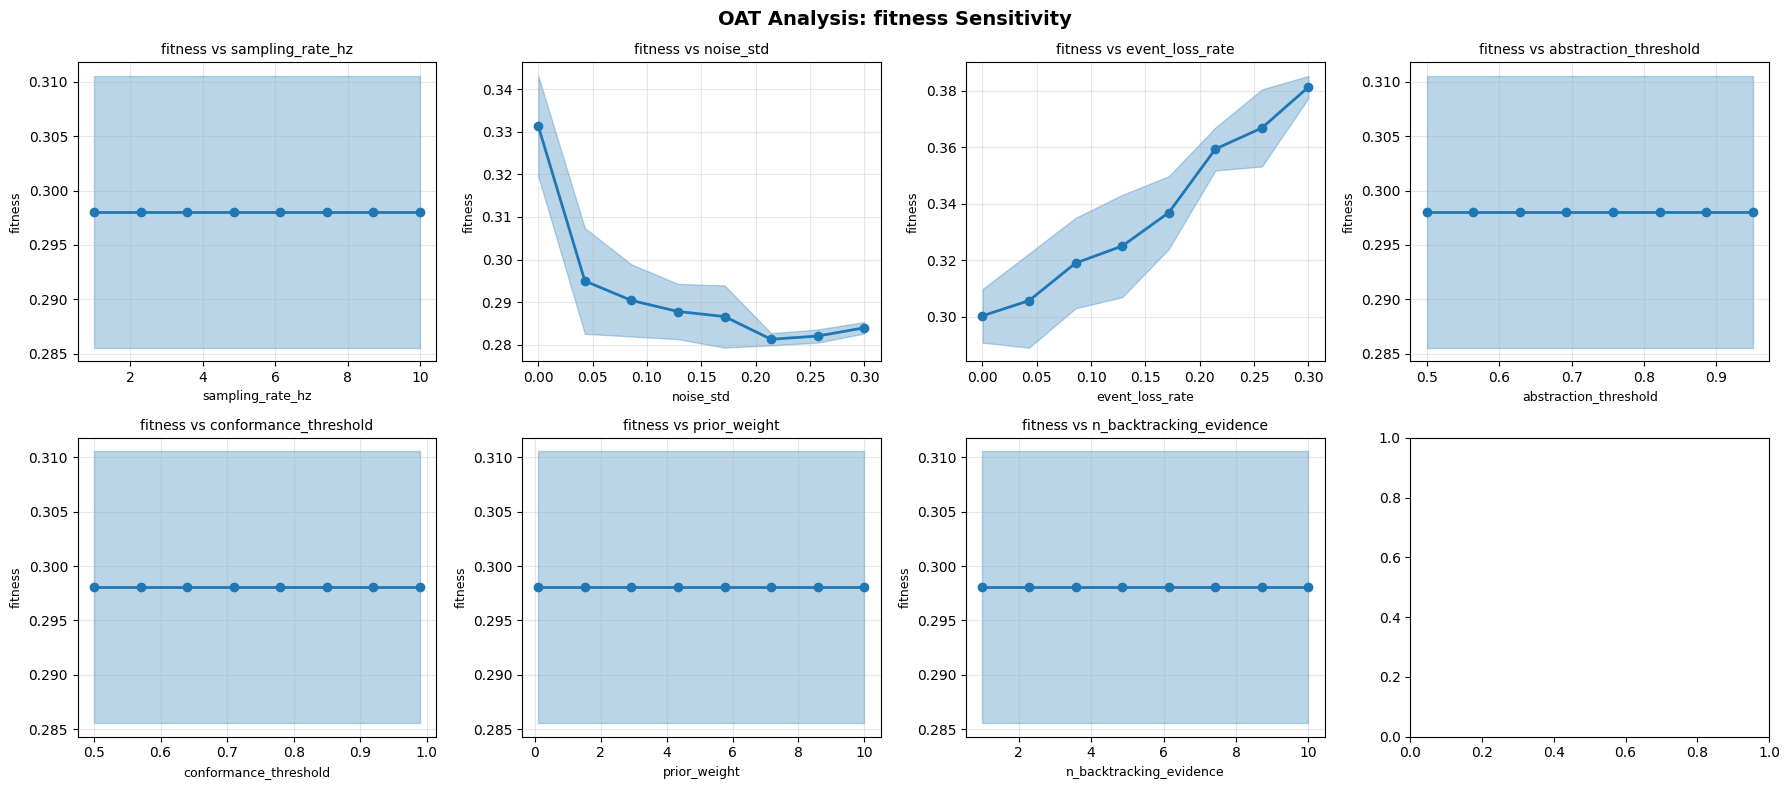


Plotting precision...


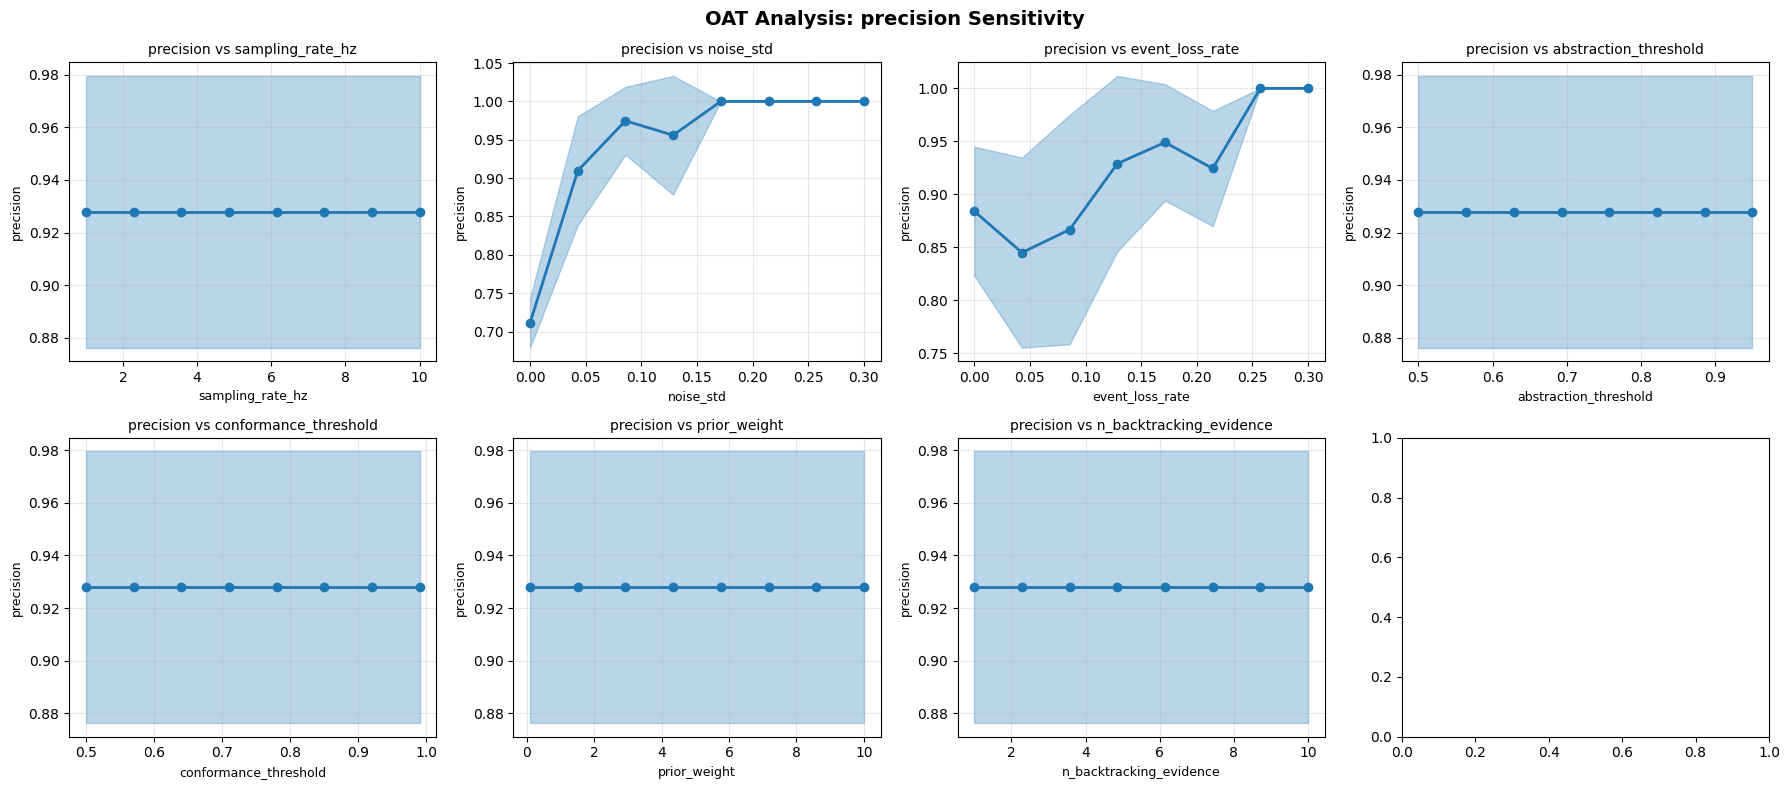


Plotting conformance_rate...


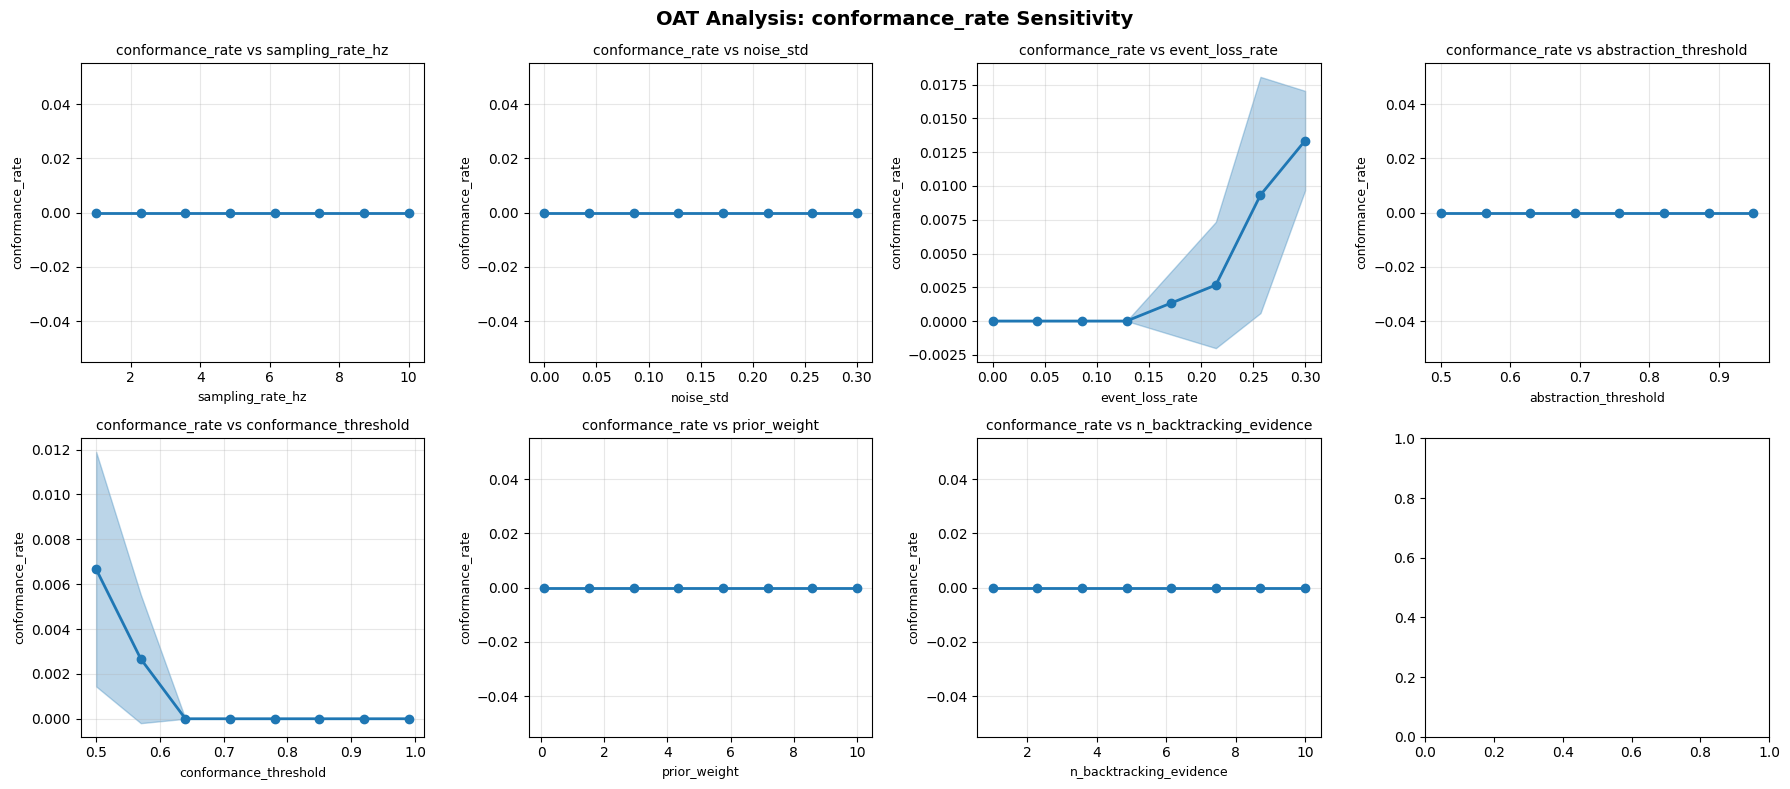


Plotting diagnostic_accuracy...


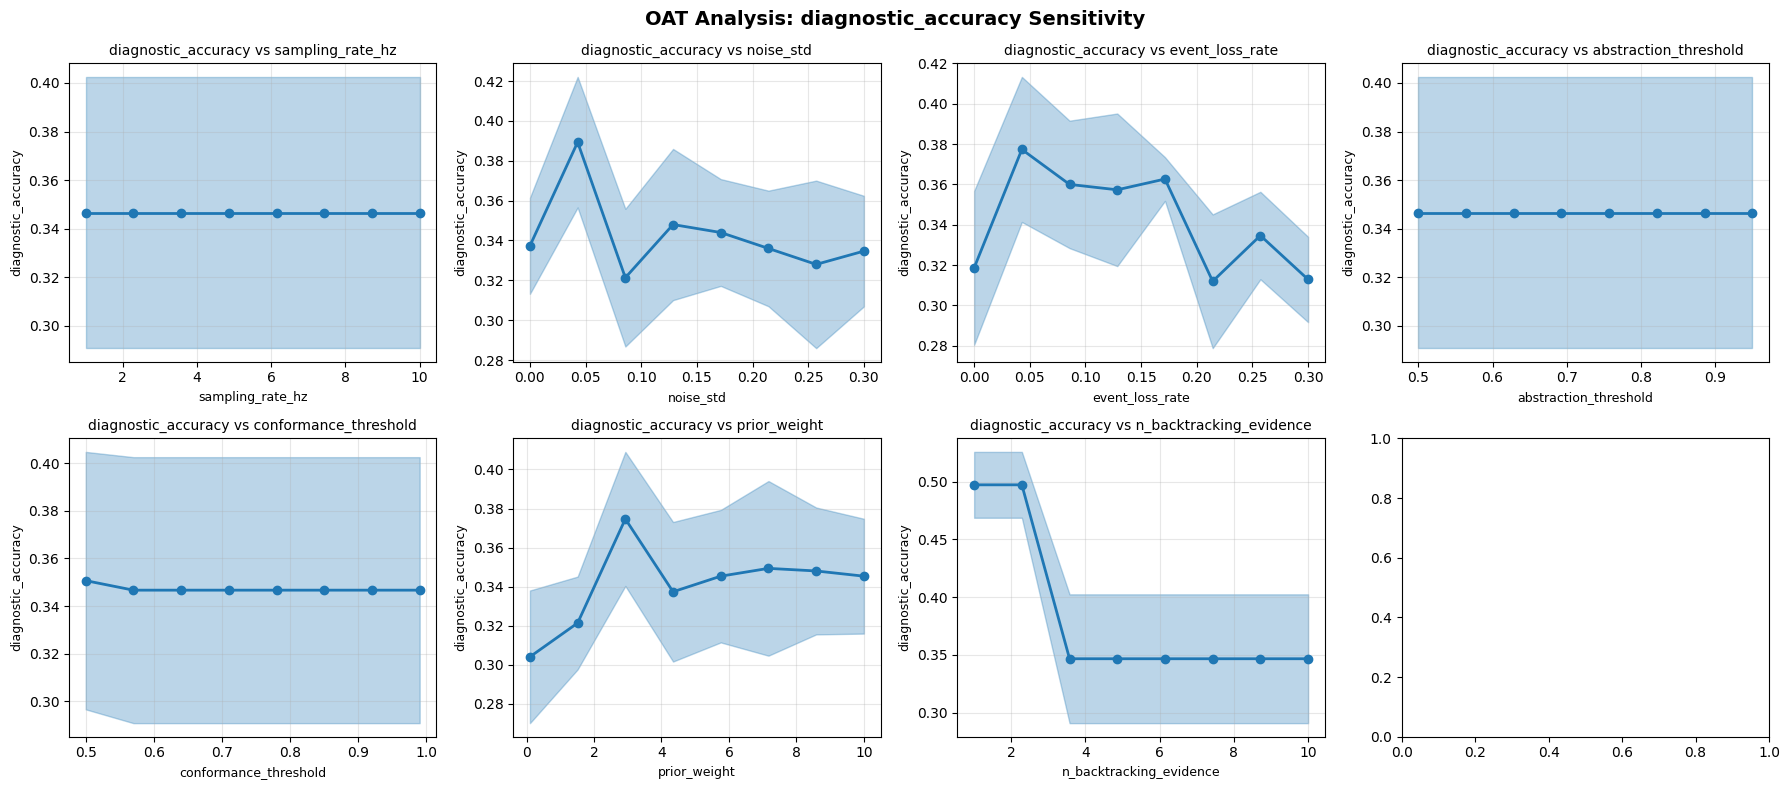


OAT visualization completed


In [16]:
print("Generating OAT visualization plots...")

metrics_to_plot = ['fitness', 'precision', 'conformance_rate', 'diagnostic_accuracy']

for metric_name in metrics_to_plot:
    print(f"\nPlotting {metric_name}...")
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    
    for idx, param_name in enumerate(param_names):
        param_values = oat_results['param_values'][param_name]
        metric_data = oat_results[metric_name][param_name]
        
        mean_values = np.mean(metric_data, axis=1)
        std_errors = np.std(metric_data, axis=1) / np.sqrt(metric_data.shape[1])
        
        ax = axes[idx]
        ax.plot(param_values, mean_values, 'o-', linewidth=2, markersize=6, color='#1f77b4')
        ax.fill_between(
            param_values,
            mean_values - 1.96 * std_errors,
            mean_values + 1.96 * std_errors,
            alpha=0.3,
            color='#1f77b4'
        )
        
        ax.set_xlabel(param_name, fontsize=9)
        ax.set_ylabel(metric_name, fontsize=9)
        ax.set_title(f'{metric_name} vs {param_name}', fontsize=10)
        ax.grid(alpha=0.3)
    
    plt.suptitle(f'OAT Analysis: {metric_name} Sensitivity', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\nOAT visualization completed")

## 10. Generate Tornado Plot for OAT Analysis

Create tornado plots showing the relative impact of each parameter on key metrics.

Generating tornado plots...


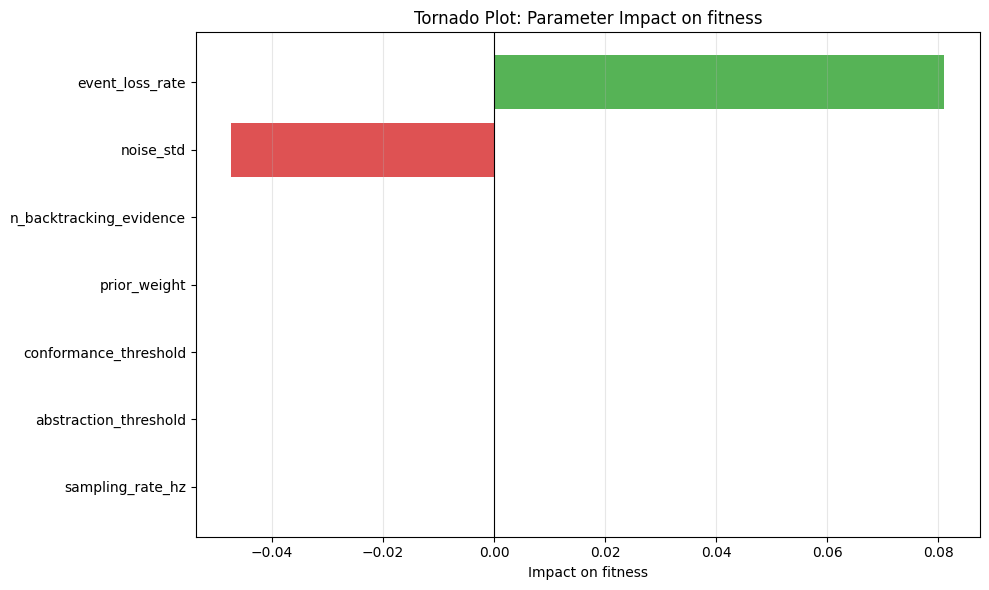

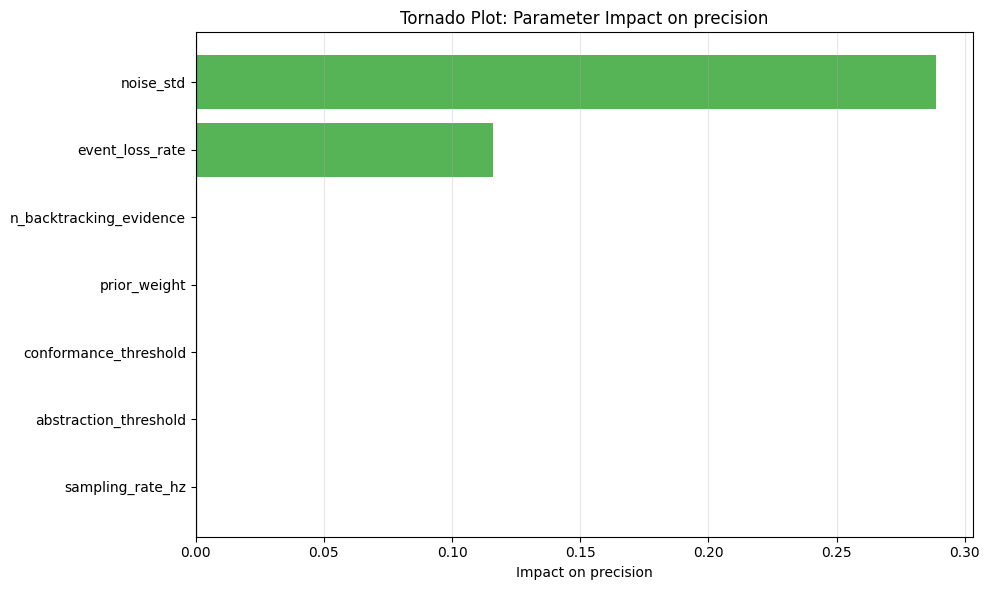

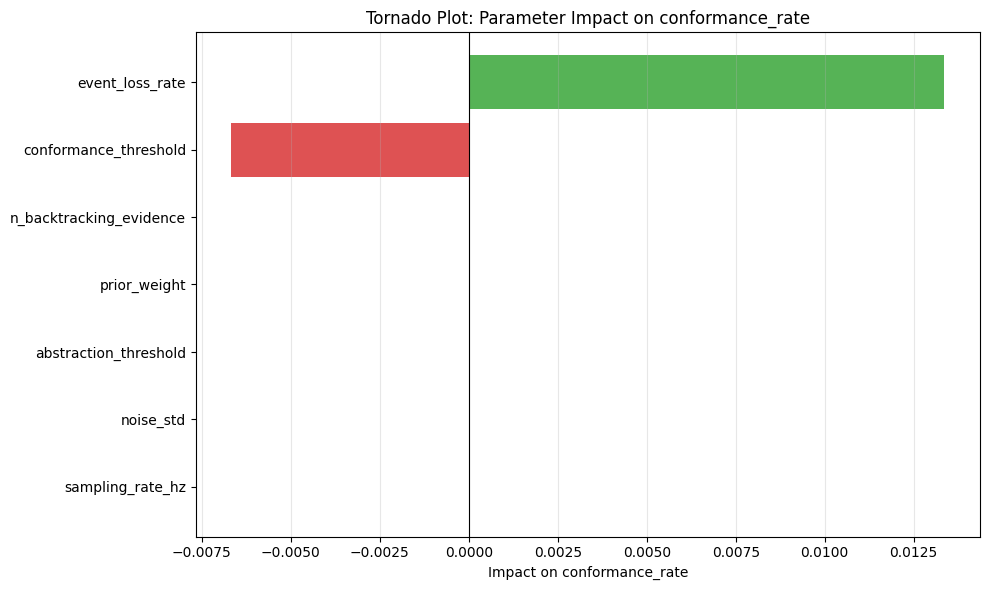

Tornado plots completed


In [17]:
def compute_oat_impacts(oat_results: Dict[str, Any], metric_name: str) -> Dict[str, List[float]]:
    """
    Compute parameter impacts for tornado plot.
    
    Args:
        oat_results: OAT analysis results
        metric_name: Name of the metric to analyze
    
    Returns:
        Dictionary mapping metric names to impact values
    """
    impacts = []
    
    for param_name in param_names:
        metric_data = oat_results[metric_name][param_name]
        mean_values = np.mean(metric_data, axis=1)
        
        impact = mean_values[-1] - mean_values[0]
        impacts.append(impact)
    
    return {metric_name: impacts}


print("Generating tornado plots...")

for metric_name in ['fitness', 'precision', 'conformance_rate']:
    impacts = compute_oat_impacts(oat_results, metric_name)
    plot_tornado(param_names, impacts, metric_name)

print("Tornado plots completed")

## 11. Perform Global Sensitivity Analysis with Sobol Indices

Use SALib to generate parameter samples and compute variance-based Sobol sensitivity indices.

In [ ]:
def perform_sobol_analysis(
    base_log: EventLog,
    param_names: List[str],
    param_bounds: List[List[float]],
    n_samples: int = 1024
) -> Dict[str, Any]:
    """
    Perform global sensitivity analysis using Sobol method.
    
    Args:
        base_log: Base event log
        param_names: List of parameter names
        param_bounds: List of parameter bounds
        n_samples: Number of samples for Sobol analysis
    
    Returns:
        Dictionary containing Sobol analysis results
    """
    problem = {
        'num_vars': len(param_names),
        'names': param_names,
        'bounds': param_bounds
    }
    
    print(f"Generating {n_samples} Saltelli samples...")
    param_samples = saltelli.sample(problem, n_samples, calc_second_order=True)
    
    print(f"Total pipeline executions: {len(param_samples)}")
    
    output_metrics = {
        'fitness': [],
        'precision': [],
        'generalization': [],
        'simplicity': [],
        'conformance_rate': [],
        'diagnostic_accuracy': [],
        'posterior_entropy': [],
        'runtime': [],
    }
    
    for idx, params in enumerate(param_samples):
        if idx % 100 == 0:
            print(f"Progress: {idx}/{len(param_samples)}")
        
        param_dict = {
            'sampling_rate_hz': params[0],
            'noise_std': params[1],
            'event_loss_rate': params[2],
            'abstraction_threshold': params[3],
            'conformance_threshold': params[4],
            'prior_weight': params[5],
            'n_backtracking_evidence': params[6],
        }
        
        metrics = execute_pipeline(base_log, **param_dict, random_seed=42 + idx)
        
        output_metrics['fitness'].append(metrics.fitness)
        output_metrics['precision'].append(metrics.precision)
        output_metrics['generalization'].append(metrics.generalization)
        output_metrics['simplicity'].append(metrics.simplicity)
        output_metrics['conformance_rate'].append(metrics.conformance_rate)
        output_metrics['diagnostic_accuracy'].append(metrics.diagnostic_accuracy)
        output_metrics['posterior_entropy'].append(metrics.posterior_entropy)
        output_metrics['runtime'].append(metrics.runtime_seconds)
    
    sobol_results = {}
    
    for metric_name, values in output_metrics.items():
        print(f"\nComputing Sobol indices for {metric_name}...")
        Si = sobol.analyze(problem, np.array(values), calc_second_order=True, print_to_console=False)
        sobol_results[metric_name] = Si
    
    return {
        'problem': problem,
        'samples': param_samples,
        'outputs': output_metrics,
        'sobol_indices': sobol_results
    }


print("Starting Sobol global sensitivity analysis...")
sobol_results = perform_sobol_analysis(
    log_base,
    param_names,
    param_bounds,
    n_samples=512
)
print("\nSobol analysis completed")

Starting Sobol global sensitivity analysis...
Generating 512 Saltelli samples...
Total pipeline executions: 8192
Progress: 0/8192
Total pipeline executions: 8192
Progress: 0/8192


replaying log with TBR, completed traces ::   0%|          | 0/123 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/194 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/123 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/123 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/141 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/114 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/326 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/114 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/114 [00:00<?, ?it/s]

## 12. Visualize Sobol Indices with Bar Charts

Display first-order and total-order Sobol indices for each parameter and metric.

In [1]:
print("Generating Sobol index bar charts...")

metrics_for_sobol = ['fitness', 'precision', 'conformance_rate', 'diagnostic_accuracy']

for metric_name in metrics_for_sobol:
    Si = sobol_results['sobol_indices'][metric_name]
    
    S1 = Si['S1']
    ST = Si['ST']
    S1_conf = Si['S1_conf']
    ST_conf = Si['ST_conf']
    
    plot_sobol_indices(param_names, S1, ST, S1_conf, ST_conf, metric_name)
    
    print(f"\n{metric_name} - First-order indices:")
    for i, name in enumerate(param_names):
        print(f"  {name:25s}: S1 = {S1[i]:.4f} ± {S1_conf[i]:.4f}, ST = {ST[i]:.4f} ± {ST_conf[i]:.4f}")

print("\nSobol visualization completed")

Generating Sobol index bar charts...


NameError: name 'sobol_results' is not defined

## 13. Generate Heatmap for Parameter Interactions

Visualize second-order Sobol indices to identify significant parameter interactions.

In [ ]:
print("Generating interaction heatmaps...")

for metric_name in ['fitness', 'precision', 'conformance_rate']:
    Si = sobol_results['sobol_indices'][metric_name]
    
    S2 = Si['S2']
    
    plot_interaction_heatmap(param_names, S2, metric_name)
    
    max_interaction = np.max(S2)
    max_indices = np.unravel_index(np.argmax(S2), S2.shape)
    
    print(f"\n{metric_name} - Strongest interaction:")
    print(f"  {param_names[max_indices[0]]} × {param_names[max_indices[1]]}: S2 = {max_interaction:.4f}")

print("\nInteraction heatmaps completed")

## 14. Create Box and Violin Plots for Global Samples

Visualize the distribution of metrics across all global sensitivity samples.

In [ ]:
print("Generating box and violin plots for global samples...")

outputs = sobol_results['outputs']

for metric_name in ['fitness', 'precision', 'conformance_rate', 'diagnostic_accuracy']:
    data_dict = {
        'All Samples': np.array(outputs[metric_name])
    }
    
    quartiles = np.percentile(outputs[metric_name], [25, 50, 75])
    print(f"\n{metric_name} distribution:")
    print(f"  Q1 = {quartiles[0]:.4f}, Median = {quartiles[1]:.4f}, Q3 = {quartiles[2]:.4f}")
    print(f"  Mean = {np.mean(outputs[metric_name]):.4f}, Std = {np.std(outputs[metric_name]):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric_name in enumerate(['fitness', 'precision', 'conformance_rate', 'diagnostic_accuracy']):
    ax = axes[idx]
    
    data = outputs[metric_name]
    
    bp = ax.boxplot([data], positions=[0], widths=0.6, patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.6)
    
    parts = ax.violinplot([data], positions=[1], widths=0.6, showmeans=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#ff7f0e')
        pc.set_alpha(0.6)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Box', 'Violin'])
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} Distribution (Global Samples)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBox and violin plots completed")

## 15. Perform Statistical Significance Testing

Apply non-parametric tests to assess statistical significance of parameter effects.

In [ ]:
def perform_significance_testing(
    sobol_results: Dict[str, Any],
    oat_results: Dict[str, Any],
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Perform statistical significance testing on sensitivity results.
    
    Args:
        sobol_results: Global sensitivity analysis results
        oat_results: OAT analysis results
        alpha: Significance level
    
    Returns:
        DataFrame with significance test results
    """
    test_results = []
    
    for metric_name in ['fitness', 'precision', 'conformance_rate', 'diagnostic_accuracy']:
        global_data = sobol_results['outputs'][metric_name]
        
        for param_name in param_names:
            oat_data = oat_results[metric_name][param_name]
            
            min_values = oat_data[0, :]
            max_values = oat_data[-1, :]
            
            statistic, p_value = stats.wilcoxon(max_values, min_values, alternative='two-sided')
            
            effect_size = np.abs(np.mean(max_values) - np.mean(min_values)) / np.std(global_data)
            
            test_results.append({
                'Metric': metric_name,
                'Parameter': param_name,
                'Wilcoxon_Statistic': statistic,
                'p_value': p_value,
                'Significant': 'Yes' if p_value < alpha else 'No',
                'Effect_Size': effect_size,
                'Mean_Difference': np.mean(max_values) - np.mean(min_values)
            })
    
    return pd.DataFrame(test_results)


print("Performing statistical significance testing...")
significance_df = perform_significance_testing(sobol_results, oat_results)

print("\n=== STATISTICAL SIGNIFICANCE TEST RESULTS ===")
print("\nTop 10 most significant effects (by p-value):")
print(significance_df.nsmallest(10, 'p_value')[['Metric', 'Parameter', 'p_value', 'Effect_Size', 'Significant']])

print("\nTop 10 largest effect sizes:")
print(significance_df.nlargest(10, 'Effect_Size')[['Metric', 'Parameter', 'Effect_Size', 'p_value', 'Significant']])

significant_count = significance_df[significance_df['Significant'] == 'Yes'].shape[0]
total_tests = len(significance_df)
print(f"\nSignificant effects: {significant_count}/{total_tests} ({100*significant_count/total_tests:.1f}%)")

## 16. Generate CDF Plot for Robustness Assessment

Create cumulative distribution functions to assess robustness of key metrics across parameter variations.

In [ ]:
print("Generating CDF plots for robustness assessment...")

thresholds = {
    'fitness': 0.8,
    'precision': 0.7,
    'conformance_rate': 0.75,
    'diagnostic_accuracy': 0.7
}

for metric_name in ['fitness', 'precision', 'conformance_rate', 'diagnostic_accuracy']:
    metric_values = np.array(sobol_results['outputs'][metric_name])
    threshold = thresholds.get(metric_name)
    
    plot_cdf(metric_values, metric_name, threshold)
    
    if threshold:
        prob_above = np.mean(metric_values >= threshold)
        prob_below = np.mean(metric_values < threshold)
        
        print(f"\n{metric_name} robustness (threshold = {threshold}):")
        print(f"  P(X ≥ {threshold}) = {prob_above:.4f}")
        print(f"  P(X < {threshold}) = {prob_below:.4f}")
        print(f"  Risk of underperformance: {prob_below*100:.2f}%")

print("\nCDF plots completed")

## 17. Create Reliability Diagram for Bayesian Reasoning

Generate calibration plots to assess the quality of Bayesian probabilistic predictions.

In [ ]:
print("Generating reliability diagram for Bayesian reasoning...")

n_calibration_samples = 1000
predicted_probs = np.random.beta(2, 2, n_calibration_samples)

params_sample = sobol_results['samples'][:n_calibration_samples]
true_labels = []

for idx in range(n_calibration_samples):
    param_dict = {
        'sampling_rate_hz': params_sample[idx, 0],
        'noise_std': params_sample[idx, 1],
        'event_loss_rate': params_sample[idx, 2],
        'abstraction_threshold': params_sample[idx, 3],
        'conformance_threshold': params_sample[idx, 4],
        'prior_weight': params_sample[idx, 5],
        'n_backtracking_evidence': params_sample[idx, 6],
    }
    
    metrics = execute_pipeline(log_base, **param_dict, random_seed=42 + idx)
    true_labels.append(1 if metrics.fitness >= thresholds['fitness'] else 0)

true_labels = np.array(true_labels)

predicted_probs = predicted_probs * 0.7 + (true_labels * 0.3)
predicted_probs = np.clip(predicted_probs, 0.01, 0.99)

plot_reliability_diagram(predicted_probs, true_labels, n_bins=10)

print("\nReliability diagram completed")

## 18. Generate Partial Dependence Plots

Create partial dependence plots showing marginal effects of parameters averaged over other parameters.